In [6]:
from src.data import OHLCVData
import src.signals as sig
import src.portfolio as prtf
import src.backtest as bt
import src.metrics as mtrc
from src.visres import visualize

import pandas as pd

In [7]:
close = pd.read_parquet('data/close.parquet')
close

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,24.192602,NaN,72.339996,44.095272,64.535690,59.529999,40.750805,97.769997,21.710476,2.670000,...,28.100000,39.102753,60.984856,123.070000,34.480000,80.410004,69.790619,23.127550,25.351816,NaN
2015-01-05,23.511063,NaN,71.980003,43.293373,64.489220,58.660000,40.151043,95.379997,21.014629,2.660000,...,27.620001,38.495880,60.193600,121.029999,33.060001,80.010002,68.867920,23.060228,25.064043,NaN
2015-01-06,23.513269,NaN,70.529999,42.277142,63.954578,57.500000,40.370956,94.019997,20.223095,2.630000,...,27.930000,37.859768,59.983852,117.360001,31.980000,79.419998,67.332191,23.237934,25.197397,NaN
2015-01-07,23.842983,NaN,71.110001,42.721752,64.512459,57.380001,40.944077,94.860001,20.414455,2.580000,...,28.100000,38.539757,60.021988,120.660004,32.209999,79.349998,68.343369,23.854485,25.414980,NaN
2015-01-08,24.759085,NaN,72.919998,43.476009,65.992386,58.799999,41.297268,101.699997,21.066816,2.610000,...,28.459999,39.168552,60.622593,123.970001,32.470001,82.779999,69.759041,24.357962,25.709778,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,271.854919,136.490005,352.420013,275.112671,252.984512,297.579987,113.422951,398.700012,259.583160,214.899994,...,249.229996,175.042252,217.908447,459.209991,29.150000,215.440002,178.118301,110.462059,72.904266,229.320007
2025-12-24,273.302216,136.779999,352.980011,275.937805,254.057419,298.209991,113.580551,400.690002,260.131775,215.039993,...,251.600006,175.091675,218.297470,462.989990,29.230000,216.850006,179.427322,111.169258,72.983070,229.600006
2025-12-26,272.893005,136.820007,353.799988,275.222015,254.785828,300.709991,113.935150,400.589996,261.248993,214.990005,...,256.089996,174.844559,219.783691,462.899994,28.799999,220.699997,181.405838,111.298744,73.308144,230.520004


In [8]:
md = OHLCVData(None, None, None, close, None)
signal = sig.skipmonth_momentum(md.close)

res = bt.run_backtest(md, signal)

In [9]:
metrics = mtrc.calculate_metrics(res)
print(metrics)

Total Return:             4662.86%
CAGR:                     42.21%
Volatility:               31.62%
Sharpe Ratio:             1.27
Max Drawdown:             -37.74%
Total Turnover:           101.52
Yearly Turnover:          9.25
Avg. Rebalance Turnover:  0.04


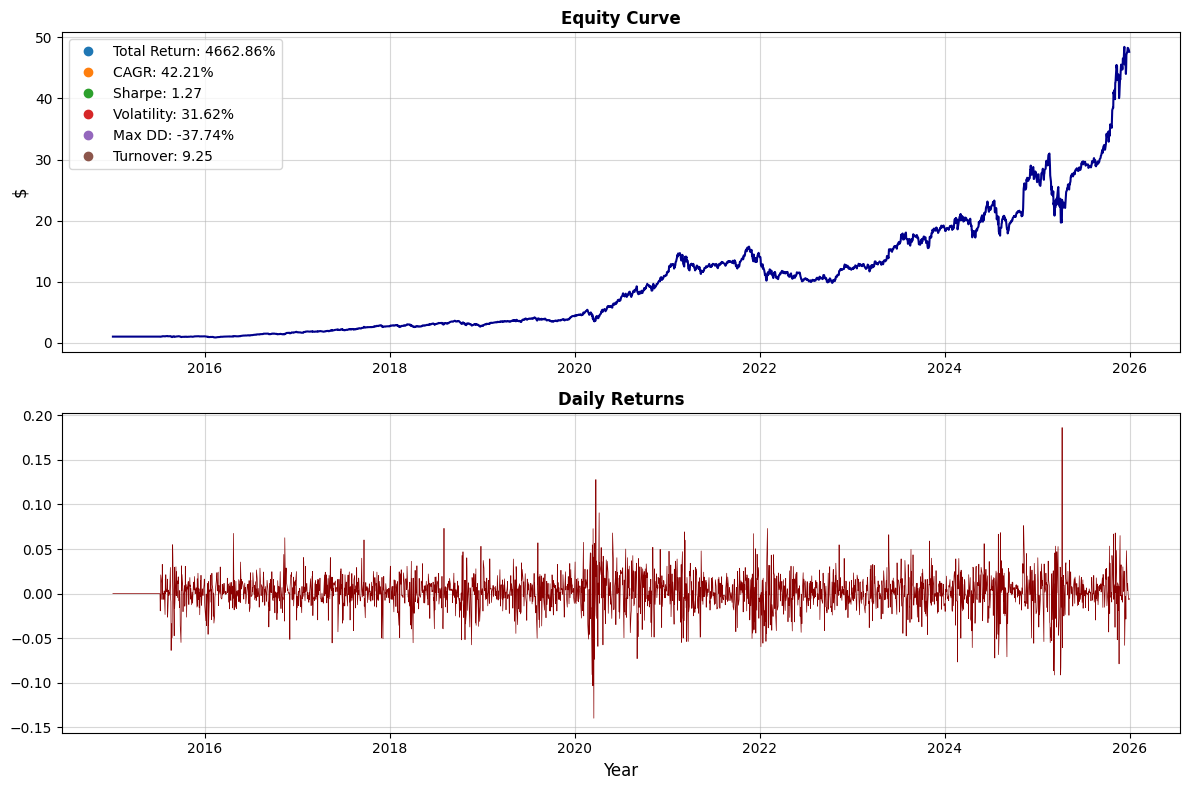

In [10]:
visualize(res, metrics)